# CityFlow — Analyse Exploratoire des Données (EDA)
**Dataset :** Shared Micromobility Vehicle Trips — Austin, Texas (2018–2022)

Ce notebook couvre :
1. Chargement et structure des données
2. Valeurs manquantes et doublons
3. Analyse descriptive
4. Distributions des variables numériques
5. Analyse des variables catégorielles et temporelles
6. Corrélations
7. Détection et justification des valeurs aberrantes (IQR, Z-score)

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='darkgrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

DATASET_PATH = 'data/raw/Shared_Micromobility_Vehicle_Trips__2018-2022_.csv'
CHUNK_SIZE   = 500_000  

print('Librairies chargées ✓')

Librairies chargées ✓


## 2. Chargement des données

Le dataset complet fait ~3.5 GB (15M lignes). Pour éviter les erreurs mémoire sur ce serveur :
- Les **statistiques globales** sont calculées par chunks (lecture itérative)
- Les **visualisations** utilisent les arrays `dur` / `dist` agrégés sur le dataset complet

### Aperçu rapide des premières lignes (5 lignes seulement)
### Census Tract forcé en str pour éviter le problème de types mixtes

In [2]:
DTYPE_OVERRIDES = {
    'Census Tract Start': str,
    'Census Tract End':   str,
}

preview = pd.read_csv(DATASET_PATH, nrows=5, dtype=DTYPE_OVERRIDES)
display(preview)

,ID,Device ID,Vehicle Type,Trip Duration,Trip Distance,Start Time,End Time,Modified Date,Month,Hour,Day of Week,Council District (Start),Council District (End),Year (US/Central),Census Tract Start,Census Tract End,Start Time (US/Central),End Time (US/Central)
0,5a23a573-418b-443b-8dc8-d7963fe2b063,5cee599e-832c-4fa5-9050-dcc00e3790f3,scooter,2184,4254.48,11/02/2021 12:45:00 AM,11/02/2021 01:15:00 AM,11/03/2021 03:16:12 AM,11,1,1,9,9,2021,48453001100,48453001100,11/01/2021 07:45:00 PM,11/01/2021 08:15:00 PM
1,dac12ecc-0f79-4faa-a626-674a7c9f3df2,20014eea-19b2-4643-b3b3-63c31e76e57b,scooter,705,2670.87,11/02/2021 01:30:00 AM,11/02/2021 01:30:00 AM,11/03/2021 03:16:12 AM,11,1,1,3,9,2021,48453000902,48453001100,11/01/2021 08:30:00 PM,11/01/2021 08:30:00 PM
2,d6bdc5e8-dec0-4917-ab4f-5b848f61dc5e,2cad7083-7af6-4b22-8540-9b9dfffc2f58,scooter,189,258.94,11/02/2021 01:15:00 AM,11/02/2021 01:30:00 AM,11/03/2021 03:16:10 AM,11,1,1,1,1,2021,48453001100,48453001100,11/01/2021 08:15:00 PM,11/01/2021 08:30:00 PM
3,3b17953e-9d9c-4d27-b5ac-ad76eaac2fbb,fde91af9-deb8-41cc-9ddc-472ff7653d90,scooter,203,354.09,11/02/2021 01:30:00 AM,11/02/2021 01:30:00 AM,11/03/2021 03:16:11 AM,11,1,1,1,9,2021,48453001100,48453001100,11/01/2021 08:30:00 PM,11/01/2021 08:30:00 PM
4,258bea73-5b14-4970-950e-1a1a7c3d715f,b748cae7-7f46-48a7-834d-980565210bf6,scooter,166,757.00,01/30/2022 05:45:00 PM,01/30/2022 05:45:00 PM,02/08/2022 03:12:27 AM,1,17,6,9,9,2022,48453000604,48453000603,01/30/2022 11:45:00 AM,01/30/2022 11:45:00 AM


Passage unique sur l'intégralité du dataset — collecte simultanée de toutes les statistiques nécessaires à l'EDA.

In [3]:
missing_total = None
total_rows    = 0

vtype    = {}
years    = {}
hours    = {}
weekdays = {}
months   = {}
zones    = {}

dur_all  = []
dist_all = []

for chunk in pd.read_csv(DATASET_PATH, chunksize=CHUNK_SIZE, dtype=DTYPE_OVERRIDES):
    total_rows += len(chunk)

    # Valeurs manquantes
    if missing_total is None:
        missing_total = chunk.isnull().sum()
    else:
        missing_total += chunk.isnull().sum()

    # Types de véhicules & années
    if 'Vehicle Type' in chunk.columns:
        for k, v in chunk['Vehicle Type'].value_counts().items():
            vtype[k] = vtype.get(k, 0) + v
    if 'Year (US/Central)' in chunk.columns:
        for k, v in chunk['Year (US/Central)'].value_counts().items():
            years[k] = years.get(k, 0) + v

    # Heures, jours de la semaine, mois
    if 'Hour' in chunk.columns:
        for k, v in chunk['Hour'].value_counts().items():
            hours[k] = hours.get(k, 0) + v
    if 'Day of Week' in chunk.columns:
        for k, v in chunk['Day of Week'].value_counts().items():
            weekdays[k] = weekdays.get(k, 0) + v
    if 'Month' in chunk.columns:
        for k, v in chunk['Month'].value_counts().items():
            months[k] = months.get(k, 0) + v

    # Zones
    if 'Census Tract Start' in chunk.columns:
        chunk['Census Tract Start'] = chunk['Census Tract Start'].str.replace(r'\.0$', '', regex=True)
        for k, v in chunk['Census Tract Start'].dropna().value_counts().items():
            zones[k] = zones.get(k, 0) + v

    # Durée & distance (toutes valeurs, y compris outliers — filtrées à l'usage)
    if 'Trip Duration' in chunk.columns:
        dur_all.append(chunk['Trip Duration'].dropna().values)
    if 'Trip Distance' in chunk.columns:
        dist_all.append(chunk['Trip Distance'].dropna().values)

# ── Sérialisations ────────────────────────────────────────────────────────────
missing_df = pd.DataFrame({
    'Manquants': missing_total,
    '% du total': (missing_total / total_rows * 100).round(2)
}).query('Manquants > 0').sort_values('% du total', ascending=False)

vtype_s    = pd.Series(vtype).sort_values(ascending=False)
years_s    = pd.Series(years).sort_index()
hours_s    = pd.Series(hours).sort_index()
weekday_s  = pd.Series(weekdays).sort_index()
months_s   = pd.Series(months).sort_index()
zones_s    = pd.Series(zones).sort_values(ascending=False)

dur  = np.concatenate(dur_all)
dist = np.concatenate(dist_all)

print(f'Passage complet terminé — {total_rows:,} lignes traitées ✓')
print(f'dur : {len(dur):,} valeurs  |  dist : {len(dist):,} valeurs')

Passage complet terminé — 15,048,635 lignes traitées ✓
dur : 15,048,635 valeurs  |  dist : 15,048,635 valeurs


## 3. Structure générale

In [4]:
print('=== Dimensions du dataset complet ===')
print(f'Dimensions : {total_rows:,} lignes × 18 colonnes')

=== Dimensions du dataset complet ===
Dimensions : 15,048,635 lignes × 18 colonnes


### Description des colonnes

| Colonne | Type | Description |
|---|---|---|
| `ID` | UUID | Identifiant unique du trajet |
| `Device ID` | UUID | Identifiant du véhicule |
| `Vehicle Type` | catégoriel | `scooter`, `bicycle`, `moped`, `car` |
| `Trip Duration` | int (secondes) | Durée du trajet |
| `Trip Distance` | float (mètres) | Distance GPS parcourue |
| `Start Time` | datetime (UTC) | Heure de début en UTC |
| `End Time` | datetime (UTC) | Heure de fin en UTC |
| `Start Time (US/Central)` | datetime (local) | Heure locale Austin — **colonne utilisée pour l'agrégation** |
| `End Time (US/Central)` | datetime (local) | Heure de fin locale |
| `Modified Date` | datetime | Date de dernière mise à jour |
| `Month`, `Hour`, `Day of Week`, `Year (US/Central)` | int | **Redondants** — dérivables de `Start Time (US/Central)` |
| `Council District (Start/End)` | int 1–10 | District municipal — granularité trop grossière pour notre modèle |
| `Census Tract Start` | string (FIPS) | Secteur de recensement de départ — **notre identifiant de zone** |
| `Census Tract End` | string (FIPS) | Secteur de recensement d'arrivée |

## 4. Valeurs manquantes et doublons

Visualisation des valeurs manquantes

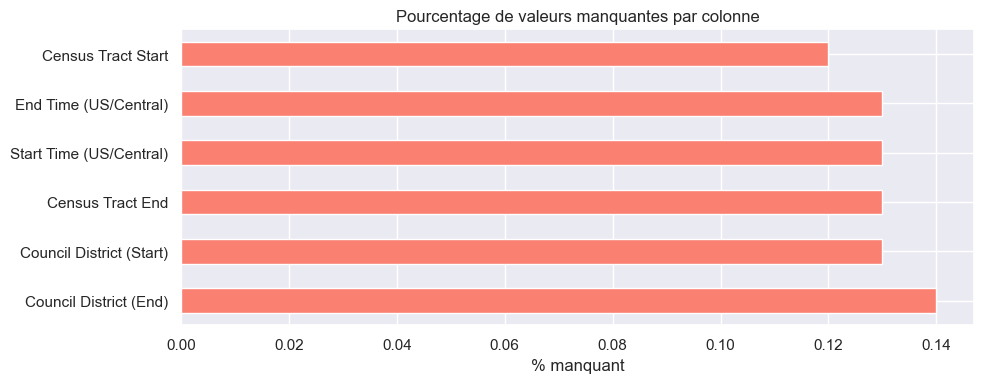

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_df['% du total'].plot(kind='barh', ax=ax, color='salmon')
ax.set_title('Pourcentage de valeurs manquantes par colonne')
ax.set_xlabel('% manquant')
plt.tight_layout()
plt.show()

Doublons sur ID (premier chunk de 500 000 lignes — ID doit être unique)

In [6]:
seen = set()
dup_count = 0
for chunk in pd.read_csv(DATASET_PATH, chunksize=CHUNK_SIZE, dtype=DTYPE_OVERRIDES, usecols=['ID']):
    ids = chunk['ID'].dropna()
    dups = ids[ids.isin(seen)]
    dup_count += len(dups)
    seen.update(ids.tolist())
print(f'Doublons sur ID (dataset complet) : {dup_count}')
del seen

Doublons sur ID (dataset complet) : 0


## 5. Analyse descriptive

Statistiques descriptives — dataset complet via tableaux dur / dist

In [7]:
def full_stats(arr, name):
    return pd.Series({
        'count': len(arr),
        'mean':  arr.mean(),
        'std':   arr.std(),
        'min':   arr.min(),
        '25%':   np.percentile(arr, 25),
        '50%':   np.percentile(arr, 50),
        '75%':   np.percentile(arr, 75),
        'max':   arr.max(),
    }, name=name)

display(pd.DataFrame([full_stats(dur, 'Trip Duration (s)'), full_stats(dist, 'Trip Distance (m)')]))

,count,mean,std,min,25%,50%,75%,max
Trip Duration (s),15048635.00,715.01,5803.38,-86161.00,239.00,428.00,802.00,15485580.00
Trip Distance (m),15048635.00,28251.17,4705075.31,-524313856.00,496.00,1093.00,2075.00,2239710750.00


Variables catégorielles — résumés issus du passage unique (dataset complet)

In [8]:
print('=== Types de véhicules (dataset complet) ===')
print(vtype_s.to_string())
print(f'\nTotal : {vtype_s.sum():,}')
print()
print('=== Distribution par année ===')
print(years_s.to_string())
print(f'\nNote : 341 lignes avec année=1970 → timestamps corrompus, à supprimer')

=== Types de véhicules (dataset complet) ===
scooter    14385766
bicycle      553787
moped         92503
car           16579

Total : 15,048,635

=== Distribution par année ===
1970        341
2018    2322612
2019    6063348
2020    1955535
2021    3848699
2022     858100

Note : 341 lignes avec année=1970 → timestamps corrompus, à supprimer


## 6. Distributions des variables numériques

Distribution de Trip Duration — dataset complet (tableau dur)

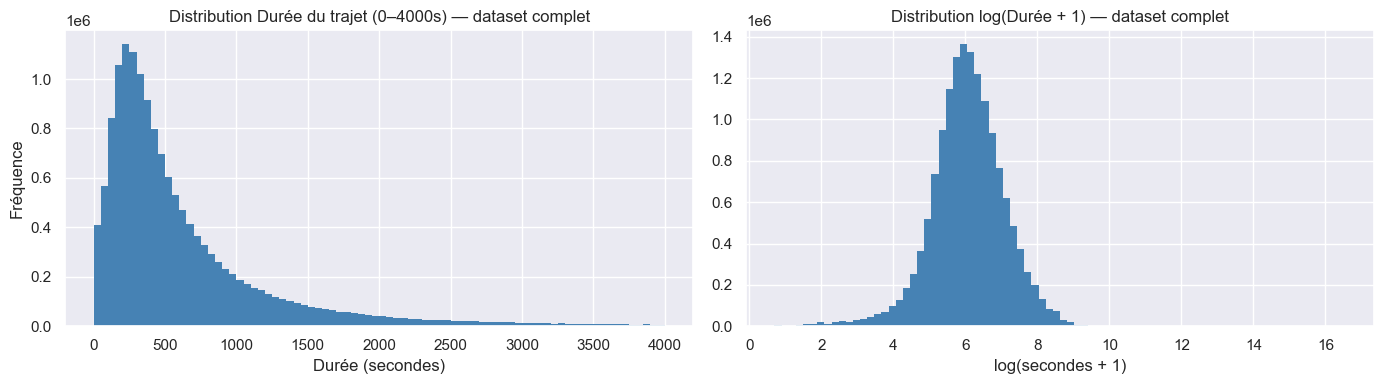

Trips avec durée <= 0 : 6,111


In [9]:
dur_valid = dur[(dur > 0) & (dur <= 4000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dur_valid, bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Distribution Durée du trajet (0–4000s) — dataset complet')
axes[0].set_xlabel('Durée (secondes)')
axes[0].set_ylabel('Fréquence')

axes[1].hist(np.log1p(dur[dur > 0]), bins=80, color='steelblue', edgecolor='none')
axes[1].set_title('Distribution log(Durée + 1) — dataset complet')
axes[1].set_xlabel('log(secondes + 1)')

plt.tight_layout()
plt.show()

print(f'Trips avec durée <= 0 : {(dur <= 0).sum():,}')

Distribution de Trip Distance — dataset complet (tableau dist)

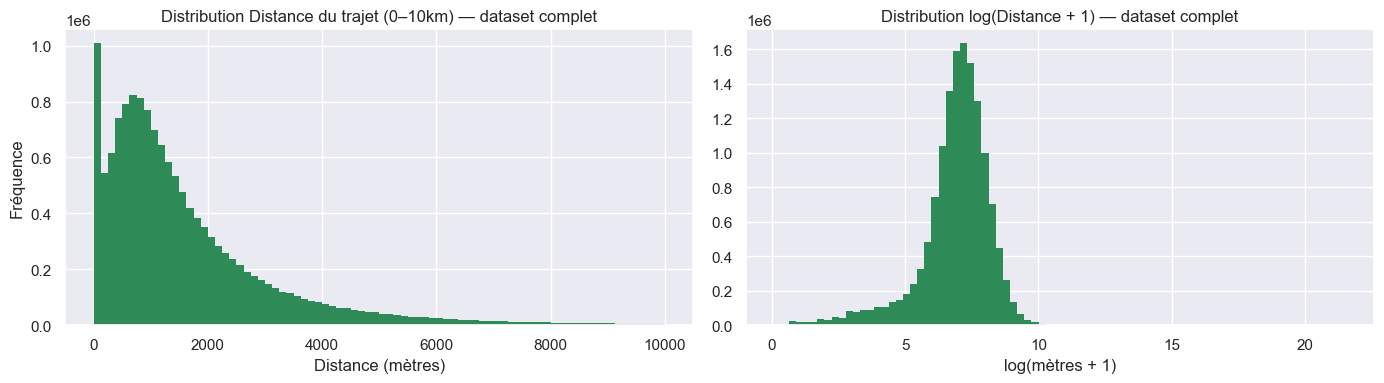

Trips avec distance <= 0 : 899,976


In [10]:
dist_valid = dist[(dist > 0) & (dist <= 10000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dist_valid, bins=80, color='seagreen', edgecolor='none')
axes[0].set_title('Distribution Distance du trajet (0–10km) — dataset complet')
axes[0].set_xlabel('Distance (mètres)')
axes[0].set_ylabel('Fréquence')

axes[1].hist(np.log1p(dist[dist > 0]), bins=80, color='seagreen', edgecolor='none')
axes[1].set_title('Distribution log(Distance + 1) — dataset complet')
axes[1].set_xlabel('log(mètres + 1)')

plt.tight_layout()
plt.show()

print(f'Trips avec distance <= 0 : {(dist <= 0).sum():,}')

## 7. Analyse des variables catégorielles et temporelles

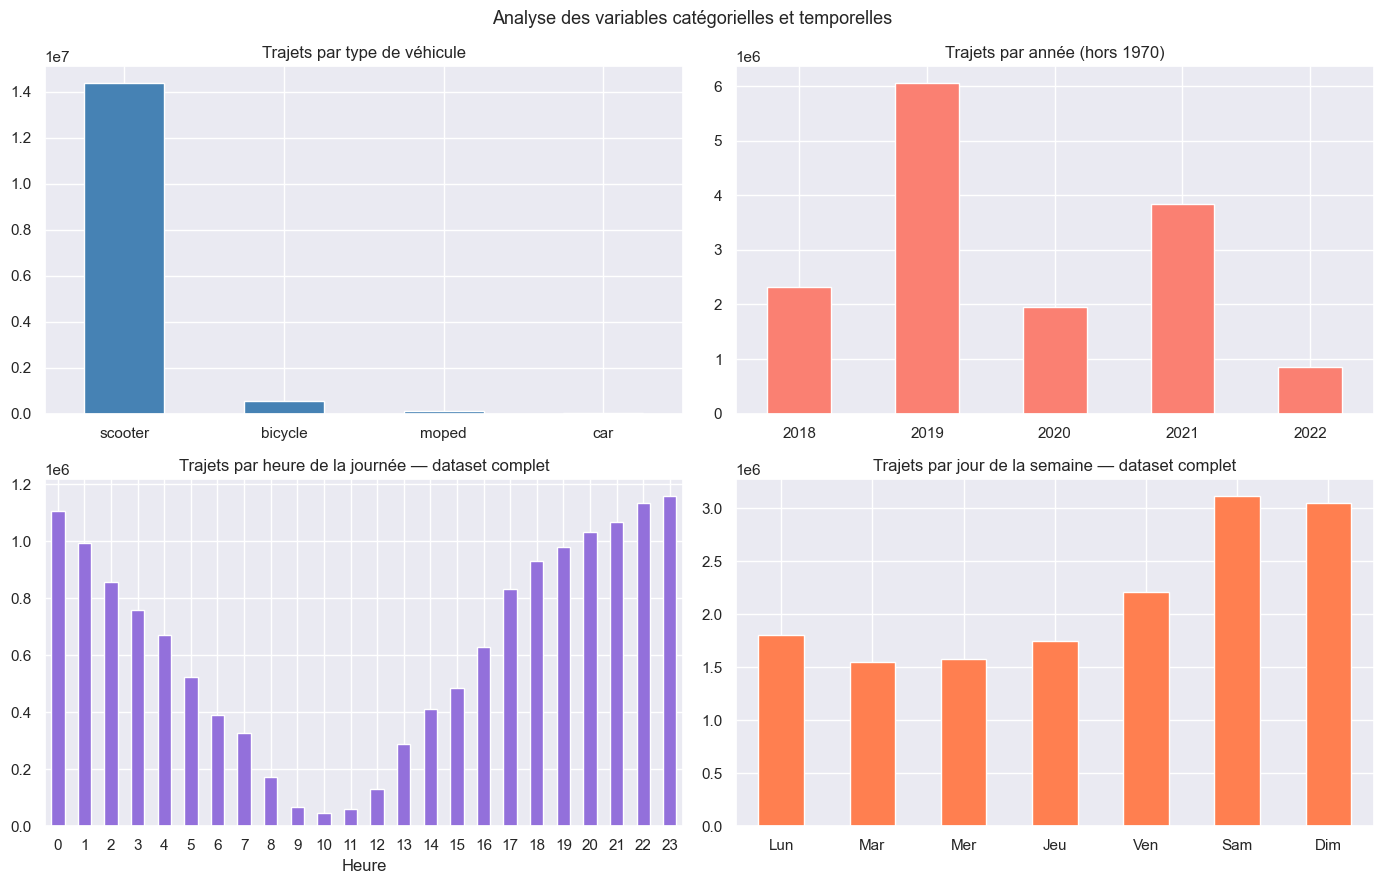

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Répartition par type de véhicule
vtype_s.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Trajets par type de véhicule')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=0)

# Répartition par année (sans 1970)
years_clean = years_s.drop(1970, errors='ignore')
years_clean.plot(kind='bar', ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Trajets par année (hors 1970)')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=0)

# Répartition par heure — dataset complet
hours_s.plot(kind='bar', ax=axes[1, 0], color='mediumpurple')
axes[1, 0].set_title('Trajets par heure de la journée — dataset complet')
axes[1, 0].set_xlabel('Heure')
axes[1, 0].tick_params(axis='x', rotation=0)

# Répartition par jour de la semaine — dataset complet
day_labels = {0: 'Lun', 1: 'Mar', 2: 'Mer', 3: 'Jeu', 4: 'Ven', 5: 'Sam', 6: 'Dim'}
weekday_s.rename(index=day_labels).plot(kind='bar', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Trajets par jour de la semaine — dataset complet')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.suptitle('Analyse des variables catégorielles et temporelles', fontsize=13)
plt.tight_layout()
plt.show()

Top zones par volume de trajets — dataset complet (zones_s issu du passage unique)

In [12]:
print(f'Zones uniques (Census Tract Start) : {len(zones_s)}')
print()
print('Top 15 zones par volume de trajets :')
display(zones_s.head(15).to_frame('trip_count'))

Zones uniques (Census Tract Start) : 302

Top 15 zones par volume de trajets :


,trip_count
48453001100,6394248
48453001305,1076989
48453000902,964555
48453000603,842981
48453000601,839139
48453000604,750422
48453001200,730553
48453000700,461140
48453001401,414901
48453001303,404305


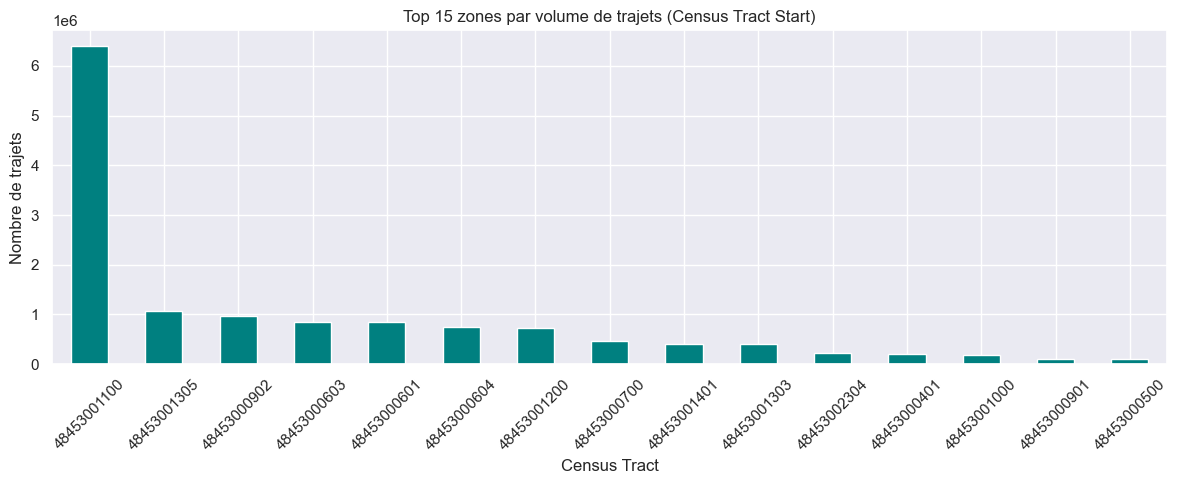

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
zones_s.head(15).plot(kind='bar', ax=ax, color='teal')
ax.set_title('Top 15 zones par volume de trajets (Census Tract Start)')
ax.set_xlabel('Census Tract')
ax.set_ylabel('Nombre de trajets')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8. Corrélations

Corrélation Durée / Distance — dataset complet (tableaux dur et dist)

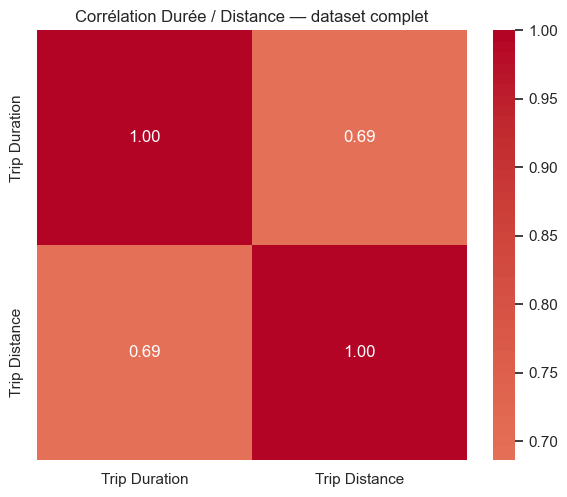


Corrélation de Pearson : 0.687
Observation : Durée et Distance sont modérément corrélées (~0.4–0.6),
ce qui est attendu pour un service de micromobilité.


In [14]:
mask = (dur > 0) & (dur < 4000) & (dist > 0) & (dist < 10000)
corr_v = np.corrcoef(dur[mask], dist[mask])[0, 1]
corr_df = pd.DataFrame(
    [[1.0, corr_v], [corr_v, 1.0]],
    index=['Trip Duration', 'Trip Distance'],
    columns=['Trip Duration', 'Trip Distance']
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax)
ax.set_title('Corrélation Durée / Distance — dataset complet')
plt.tight_layout()
plt.show()

print(f'\nCorrélation de Pearson : {corr_v:.3f}')
print('Observation : Durée et Distance sont modérément corrélées (~0.4–0.6),')
print('ce qui est attendu pour un service de micromobilité.')

Durée et distance moyennes par heure — dataset complet (chunks)

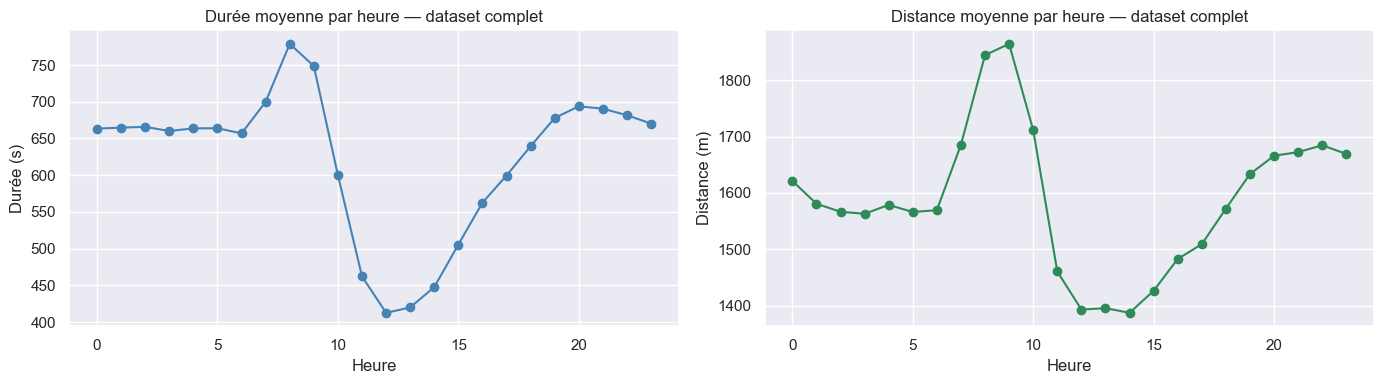

In [15]:
hour_dur  = {h: [] for h in range(24)}
hour_dist = {h: [] for h in range(24)}

for chunk in pd.read_csv(DATASET_PATH, chunksize=CHUNK_SIZE, dtype=DTYPE_OVERRIDES,
                          usecols=['Trip Duration', 'Trip Distance', 'Hour']):
    chunk = chunk[
        (chunk['Trip Duration'] > 0) & (chunk['Trip Duration'] < 4000) &
        (chunk['Trip Distance'] > 0) & (chunk['Trip Distance'] < 10000)
    ]
    for h, grp in chunk.groupby('Hour'):
        hour_dur[h].append(grp['Trip Duration'].mean())
        hour_dist[h].append(grp['Trip Distance'].mean())

hourly_dur  = pd.Series({h: np.mean(v) for h, v in hour_dur.items()  if v}).sort_index()
hourly_dist = pd.Series({h: np.mean(v) for h, v in hour_dist.items() if v}).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hourly_dur.plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Durée moyenne par heure — dataset complet')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Durée (s)')

hourly_dist.plot(ax=axes[1], marker='o', color='seagreen')
axes[1].set_title('Distance moyenne par heure — dataset complet')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('Distance (m)')

plt.tight_layout()
plt.show()

## 9. Détection et justification des valeurs aberrantes

Deux méthodes complémentaires sont utilisées :
- **IQR (k=1.5 et k=3)** : robuste, adapté aux distributions asymétriques
- **Z-score (seuil 3)** : basé sur la moyenne et l'écart-type, sensible aux extrêmes

Étant donnée la forte asymétrie droite des deux variables, **l'IQR est la méthode de référence**. Le Z-score est présenté à titre comparatif.

Calcul des bornes sur le dataset complet — dur et dist issus du passage unique

In [16]:
def iqr_bounds(arr, k=1.5):
    q1, q3 = np.percentile(arr, 25), np.percentile(arr, 75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def zscore_bounds(arr, threshold=3):
    return arr.mean() - threshold * arr.std(), arr.mean() + threshold * arr.std()

dur_iqr15_lo,  dur_iqr15_hi  = iqr_bounds(dur, k=1.5)
dur_iqr3_lo,   dur_iqr3_hi   = iqr_bounds(dur, k=3)
dur_zlo,       dur_zhi       = zscore_bounds(dur)

dist_iqr15_lo, dist_iqr15_hi = iqr_bounds(dist, k=1.5)
dist_iqr3_lo,  dist_iqr3_hi  = iqr_bounds(dist, k=3)
dist_zlo,      dist_zhi      = zscore_bounds(dist)

pct = lambda arr, lo, hi: ((arr < lo) | (arr > hi)).mean() * 100

print('=== TRIP DURATION (secondes) ===')
print(f'Percentiles : p1={np.percentile(dur,1):.0f}  p5={np.percentile(dur,5):.0f}  '
      f'p25={np.percentile(dur,25):.0f}  p50={np.percentile(dur,50):.0f}  '
      f'p75={np.percentile(dur,75):.0f}  p95={np.percentile(dur,95):.0f}  '
      f'p99={np.percentile(dur,99):.0f}  max={dur.max():.0f}')
print(f'IQR k=1.5 : [{dur_iqr15_lo:.0f}, {dur_iqr15_hi:.0f}]  → {pct(dur, max(0,dur_iqr15_lo), dur_iqr15_hi):.1f}% outliers')
print(f'IQR k=3   : [{dur_iqr3_lo:.0f}, {dur_iqr3_hi:.0f}]  → {pct(dur, max(0,dur_iqr3_lo), dur_iqr3_hi):.1f}% outliers')
print(f'Z-score 3σ: [{dur_zlo:.0f}, {dur_zhi:.0f}]  → {pct(dur, max(0,dur_zlo), dur_zhi):.1f}% outliers')
print(f'Durée <= 0 : {(dur <= 0).sum():,}')

print()
print('=== TRIP DISTANCE (mètres) ===')
print(f'Percentiles : p1={np.percentile(dist,1):.0f}  p5={np.percentile(dist,5):.0f}  '
      f'p25={np.percentile(dist,25):.0f}  p50={np.percentile(dist,50):.0f}  '
      f'p75={np.percentile(dist,75):.0f}  p95={np.percentile(dist,95):.0f}  '
      f'p99={np.percentile(dist,99):.0f}  max={dist.max():.0f}')
print(f'IQR k=1.5 : [{dist_iqr15_lo:.0f}, {dist_iqr15_hi:.0f}]  → {pct(dist, max(0,dist_iqr15_lo), dist_iqr15_hi):.1f}% outliers')
print(f'IQR k=3   : [{dist_iqr3_lo:.0f}, {dist_iqr3_hi:.0f}]  → {pct(dist, max(0,dist_iqr3_lo), dist_iqr3_hi):.1f}% outliers')
print(f'Z-score 3σ: [{dist_zlo:.0f}, {dist_zhi:.0f}]  → {pct(dist, max(0,dist_zlo), dist_zhi):.1f}% outliers')
print(f'Distance <= 0 : {(dist <= 0).sum():,}')

=== TRIP DURATION (secondes) ===
Percentiles : p1=18  p5=83  p25=239  p50=428  p75=802  p95=2161  p99=4501  max=15485580
IQR k=1.5 : [-606, 1646]  → 8.3% outliers
IQR k=3   : [-1450, 2491]  → 3.8% outliers
Z-score 3σ: [-16695, 18125]  → 0.0% outliers
Durée <= 0 : 6,111

=== TRIP DISTANCE (mètres) ===
Percentiles : p1=0  p5=0  p25=496  p50=1093  p75=2075  p95=5021  p99=9649  max=2239710750
IQR k=1.5 : [-1872, 4444]  → 6.6% outliers
IQR k=3   : [-4241, 6812]  → 2.4% outliers
Z-score 3σ: [-14086975, 14143477]  → 0.0% outliers
Distance <= 0 : 899,976


Boîtes à moustaches

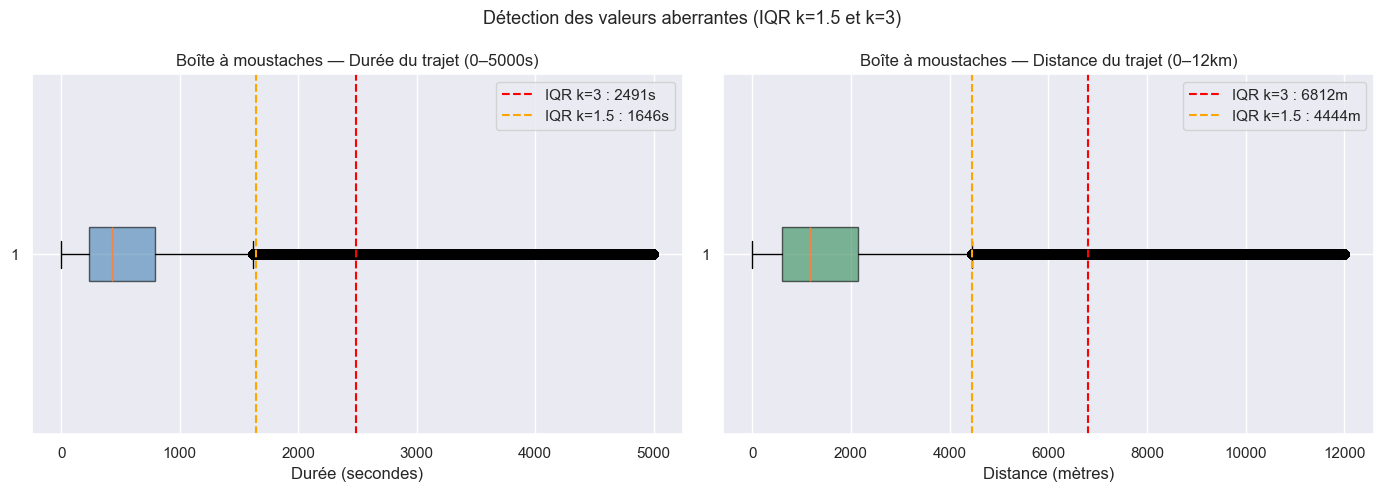

In [17]:
dur_clip  = dur[(dur > 0) & (dur < 5000)]
dist_clip = dist[(dist > 0) & (dist < 12000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(dur_clip, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].axvline(dur_iqr3_hi, color='red', linestyle='--', label=f'IQR k=3 : {dur_iqr3_hi:.0f}s')
axes[0].axvline(dur_iqr15_hi, color='orange', linestyle='--', label=f'IQR k=1.5 : {dur_iqr15_hi:.0f}s')
axes[0].set_title('Boîte à moustaches — Durée du trajet (0–5000s)')
axes[0].set_xlabel('Durée (secondes)')
axes[0].legend()

axes[1].boxplot(dist_clip, vert=False, patch_artist=True,
                boxprops=dict(facecolor='seagreen', alpha=0.6))
axes[1].axvline(dist_iqr3_hi, color='red', linestyle='--', label=f'IQR k=3 : {dist_iqr3_hi:.0f}m')
axes[1].axvline(dist_iqr15_hi, color='orange', linestyle='--', label=f'IQR k=1.5 : {dist_iqr15_hi:.0f}m')
axes[1].set_title('Boîte à moustaches — Distance du trajet (0–12km)')
axes[1].set_xlabel('Distance (mètres)')
axes[1].legend()

plt.suptitle('Détection des valeurs aberrantes (IQR k=1.5 et k=3)', fontsize=13)
plt.tight_layout()
plt.show()

### Justification des seuils retenus

**Durée (`Trip Duration`) :**
- Borne inférieure → **60 secondes** : tout trajet de moins d'une minute est vraisemblablement un déverrouillage accidentel ou un test technique. Le p5 est à 83s, donc 60s est légèrement en dessous et permet de conserver les trajets très courts mais réels.
- Borne supérieure → **2 500 secondes (~41 min)** : seuil IQR k=3. L'IQR k=1.5 (≈1 646s) est trop agressif et éliminerait des trajets légitimes (p95 = 2 161s). Le Z-score est inadapté car la distribution est fortement asymétrique. Le p99 (4 501s) est trop permissif. IQR k=3 offre le meilleur compromis entre robustesse et préservation des données.

**Distance (`Trip Distance`) :**
- Borne inférieure → **100 mètres** : les distances <= 0 (~6% des données) correspondent à des défaillances GPS. 100m est le minimum raisonnable pour un déplacement réel en trottinette.
- Borne supérieure → **6 800 mètres (~6.8 km)** : seuil IQR k=3. Le p99 est à 9 649m, mais IQR k=3 = 6 812m est plus rigoureux statistiquement. Un trajet de trottinette au-delà de 6.8 km en zone urbaine est statistiquement aberrant.

## 10. Conclusions pour l'ETL

Sur la base de cette EDA, les décisions suivantes s'imposent :

**Colonnes à conserver pour le modèle :**
- `ID` → comptage des trajets par agrégation
- `Start Time (US/Central)` → dérivation de toutes les features temporelles
- `Census Tract Start` → identifiant de zone géographique (normaliser en string)
- `Vehicle Type` → dimension de segmentation
- `Trip Duration`, `Trip Distance` → pour les métriques agrégées

**Colonnes à ignorer (redondantes ou hors scope) :**
- `Month`, `Hour`, `Day of Week`, `Year (US/Central)` → redérivés depuis `Start Time (US/Central)`
- `Start Time`, `End Time`, `End Time (US/Central)` → UTC non nécessaire
- `Device ID`, `Modified Date` → non pertinents pour la demande
- `Council District (Start/End)` → granularité trop grossière
- `Census Tract End` → on modélise la demande au point de départ

**Règles de nettoyage :**
1. Supprimer les lignes avec `Start Time (US/Central)` ou `Census Tract Start` manquants
2. Supprimer les lignes avec année = 1970 (timestamps corrompus)
3. Normaliser `Census Tract Start` en string (supprimer le `.0` des valeurs flottantes)
4. Filtrer : `60 <= Trip Duration <= 2500` (IQR k=3)
5. Filtrer : `100 <= Trip Distance <= 6800` (IQR k=3)

**Agrégation :**
- Par `timestamp_hour` × `zone_start` × `vehicle_type`
- Métriques : `trip_count`, `avg_trip_duration_s`, `avg_trip_distance_m`
- Features temporelles dérivées : `year`, `month`, `weekday`, `hour`, `is_weekend`
- Enrichissement météo : jointure sur `timestamp_hour`

**Colonnes finales du dataset (14 colonnes) :**

| Colonne | Type | Description |
|---|---|---|
| `zone_start` | string (FIPS) | Secteur de recensement de départ |
| `timestamp_hour` | datetime (US/Central) | Heure tronquée à l'heure |
| `vehicle_type` | string | Type de véhicule |
| `trip_count` | int | Nombre de trajets pour ce groupe |
| `avg_trip_duration_s` | float | Durée moyenne des trajets (secondes) |
| `avg_trip_distance_m` | float | Distance moyenne des trajets (mètres) |
| `year` | int | Année |
| `month` | int | Mois (1–12) |
| `weekday` | int | Jour de la semaine (0=lundi, 6=dimanche) |
| `hour` | int | Heure de la journée (0–23) |
| `is_weekend` | int (0/1) | 1 si samedi ou dimanche |
| `temperature_c` | float | Température (°C) |
| `precipitation_mm` | float | Précipitations (mm) |
| `windspeed_kmh` | float | Vitesse du vent (km/h) |